In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import eigvals
from scipy.linalg import solve
from scipy.stats import linregress
import powerlaw

In [2]:
# Drosophila Optic Medulla Connectome
df_dros_optic_medulla = pd.read_csv('/Users/haotianli/Code/ZhouLab/scripts/LynnReproduction/ConnectomeData/Drosophila_optic_medulla.csv',
                         header=None, names=['pre', 'post', 'weight'])

nodes = sorted(set(df_dros_optic_medulla['pre']).union(df_dros_optic_medulla['post']))
n = max(nodes)
A = np.zeros((n, n))

for _, row in df_dros_optic_medulla.iterrows():
    i, j, w = int(row['pre']), int(row['post']), row['weight']
    A[i-1, j-1] = w
    
A_sym = (A + A.T) / 2

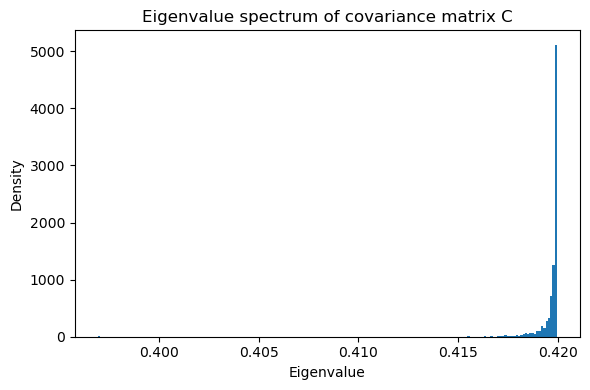

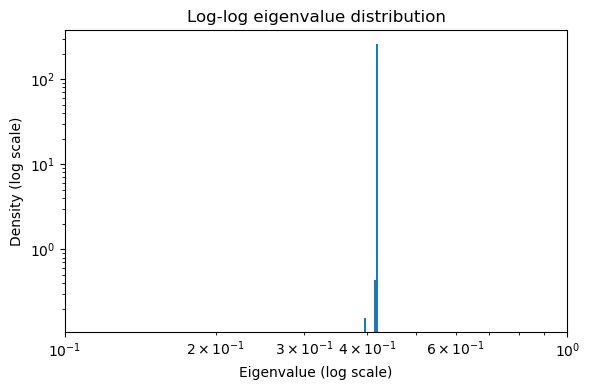

In [9]:
def neuronal_activity(A_norm, x0, beta, h, tol=1e-8, max_iter=5000):
    """
    用固定点迭代求稳态活动: x = tanh(beta * (A_norm @ x) + h)
    """
    x = x0.copy()
    for _ in range(max_iter):
        x_new = np.tanh(beta * (A_norm @ x) + h)
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x

# -------------------------
# 3. compute_C() 函数
# -------------------------
def compute_C(A, s_avg, beta):
    N = A.shape[0]
    A_norm = A / (s_avg * N)
    x0 = np.zeros(N)
    h = -np.ones(N)
    x = neuronal_activity(A_norm, x0, beta, h)
    d = 1.0 - x**2
    M = np.eye(N) - beta * (d[:, None] * A_norm)
    D_full = np.diag(d)
    X = solve(M, D_full, assume_a='gen')
    C = beta * X
    return C, A_norm, x, d

# -------------------------
# 4. 计算协方差矩阵
# -------------------------
s_avg = np.mean(A_sym.sum(axis=1))  # 平均出度
beta = 1

C, A_norm, x, d = compute_C(A_sym, s_avg, beta)

# -------------------------
# 5. 画出特征值谱
# -------------------------
eigvals = np.linalg.eigvalsh(0.5 * (C + C.T))

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(eigvals, bins=200, density=True)
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Eigenvalue spectrum of covariance matrix C")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
eigvals_pos = eigvals[eigvals > 0]
plt.hist(eigvals_pos, bins=np.logspace(-8, 0, 2000), density=True)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Eigenvalue (log scale)")
plt.ylabel("Density (log scale)")
plt.xlim(1e-1, 1)
plt.title("Log-log eigenvalue distribution")
plt.tight_layout()
plt.show()